# Pump failure example with Pareto prior

This notebook demonstrates the use of `MGFDerivative` with a Pareto prior for the Poisson likelihood, using the classic pump failure data from Gaver and O'Muircheartaigh (1987).

We will:
- Compute the model evidence (marginal likelihood)
- Compute the posterior density
- Compute the posterior predictive mass for a new observation
- Compute the posterior MGF and moments
- Demonstrate sequential updating by splitting the data into two chunks

All examples use the **single‑rate model** with a diffuse Pareto prior $ \Lambda \sim \text{Pareto}(\alpha=10^{-5}, \xi=10^{-5}) $. This matches the setup in the paper.

## Setup

In [1]:
import pandas as pd
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jumufraktiv.MGFDerivative_class import MGFDerivative
from jumufraktiv.like_stats.Poisson import readyPoisson
from scipy.special import expn
import mpmath as mp
import numpy as np
import math

plt.style.use('seaborn-v0_8-whitegrid')

## Pump failure data

In [2]:
data = pd.DataFrame({
    't': [94.32, 15.72, 62.88, 125.76, 5.24, 31.44, 1.048, 1.048, 2.096, 10.48],
    'y': [5, 1, 5, 14, 3, 19, 1, 1, 4, 22]
})
print("Data:")
display(data)

Data:


,t,y
0,94.320,5
1,15.720,1
2,62.880,5
3,125.760,14
4,5.240,3
5,31.440,19
6,1.048,1
7,1.048,1
8,2.096,4
9,10.480,22


## Prior specification

We use a Pareto prior with shape `α = 1e-5` and scale `ξ = 1e-5` (very diffuse). Note that the Poisson likelihood gives an integer derivative order (`a = sum(y_i)`), so we will use `method='symbolic'` for exact computation.

## 1. Model evidence

The evidence is computed via the derivative of the prior MGF at `t = -b`. We compute it symbolically and compare with the analytic formula from the paper.

In [3]:
# Compute evidence using the package
from jumufraktiv.mitMGFprior_class import mitMGFprior
import jumufraktiv.MGFdictionary  # registers priors

alpha_prior = 1e-5
xi_prior = 1e-5

# ---- Create Pareto prior object ----
pareto_prior = mitMGFprior.from_registry(
    "pareto",
    params={"alpha": alpha_prior, "xi": xi_prior}
)

deriv = MGFDerivative(
    prior=pareto_prior,   # prior object
    data=data['y'],
    likelihood='poisson',
    method='symbolic',
    scale=data['t']       # likelihood parameter
)

log_ev_pkg, sign_pkg = deriv.evidence()
print(f"Package log evidence: {log_ev_pkg:.6f}, sign = {sign_pkg}")

Package log evidence: -91.738538, sign = 1


**1.2 Analytical verification using the paper's formula**

The evidence for the single‑rate Pareto‑Poisson model is given by Equation (14) in the paper:

$$
p(\mathbf{y}) = \left(\prod_{i=1}^n \frac{t_i^{y_i}}{y_i!}\right) \, \alpha \, \xi^{\sum y_i} \, E_{\alpha+1-\sum y_i}\left(\xi \sum t_i\right),
$$

where $E_n(z)$ is the exponential integral function. We can verify the package result by directly substituting the hyperparameters into the symbolic derivative expression obtained from the package.

In [4]:
# Set high precision for accurate evaluation
mp.mp.dps = 50  # note: use mp.mp.dps, not mp.dps

# Compute statistics
a = sum(data['y'])
b = sum(data['t'])
c_val = np.prod(data['t']**data['y'] / [math.factorial(int(yi)) for yi in data['y']])

# Hyperparameters
alpha_prior = 1e-5
xi_prior = 1e-5

# Order and argument of the exponential integral
n_expint = alpha_prior + 1 - a
z_expint = xi_prior * b

# Evaluate E_n(z) using mpmath (supports negative n)
E_val = mp.expint(n_expint, z_expint)

# Compute log evidence
log_ev_analytic = np.log(c_val) + np.log(alpha_prior) + a * np.log(xi_prior) + np.log(float(E_val))
print(f"Analytical log evidence (mpmath): {log_ev_analytic:.6f}")

# Compare with package result (from previous chunk)
print(f"Package log evidence: {log_ev_pkg:.6f}")
print(f"Difference: {log_ev_analytic - log_ev_pkg:.2e}")

Analytical log evidence (mpmath): -91.738538
Package log evidence: -91.738538
Difference: -2.84e-14


## 2. Posterior density

The posterior density is given by (16). We compute it over a range of λ values and plot.

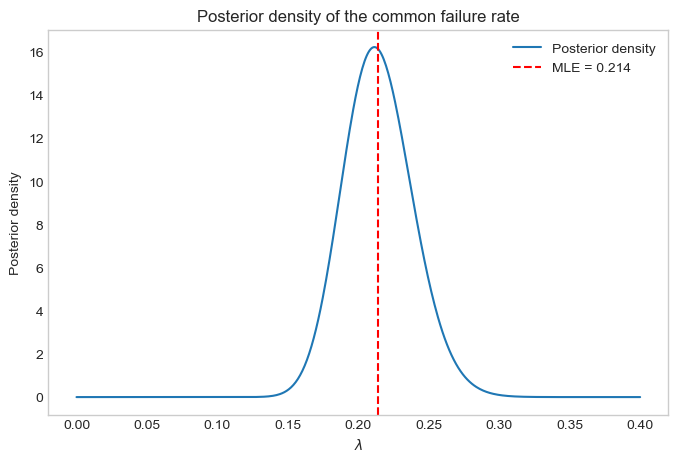

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute MLE ----
a = sum(data['y'])
b = sum(data['t'])
mle = a / b

# ---- Posterior density ----
lambda_vals = np.linspace(1e-6, 0.4, 500)
log_post = deriv.post_density(lambda_vals, log=True)
post = np.exp(log_post)

# ---- Plot ----
plt.figure(figsize=(8,5))
plt.plot(lambda_vals, post, label='Posterior density')
plt.axvline(x=mle, color='r', linestyle='--', label=f'MLE = {mle:.3f}')
plt.xlabel(r'$\lambda$')
plt.ylabel('Posterior density')
plt.title('Posterior density of the common failure rate')
plt.legend()
plt.grid()
plt.show()

In [6]:
import sympy as sp
from jumufraktiv.mitMGFprior_class import mitMGFprior
from jumufraktiv.symbols import t, theta, param
from jumufraktiv.MGFDerivative_class import MGFDerivative

# ---- Define symbolic hyperparameters for Pareto ----
alpha_sym = param("alpha")
xi_sym = param("xi")

# ---- Create a symbolic Pareto prior using the registry ----
symbolic_prior = mitMGFprior.from_registry(
    "pareto",
    params={'alpha': alpha_sym, 'xi': xi_sym}   # <-- symbols
)

# ---- Pass to MGFDerivative ----
# Use the same data (e.g., pump failure data)
deriv_sym = MGFDerivative(
    prior=symbolic_prior,
    data=data['y'],
    likelihood='poisson',
    method='auto',
    scale=data['t']
)

# ---- Check result ----
print(f"deriv_sym.is_symbolic = {deriv_sym.is_symbolic}")   # Should be True

# ---- Compute symbolic posterior density ----
post_expr = deriv_sym.post_density(theta, log=False)
print("Symbolic posterior density (Pareto prior):")
sp.pprint(post_expr, use_unicode=False)

deriv_sym.is_symbolic = False


TypeError: cannot determine truth value of Relational: theta/xi >= 1.0

## 3. Posterior predictive mass

We compute the predictive mass for a new observation at pump 4's exposure (`t_new = 125.76`) and compare with the observed `y=14`.

method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 75.0
b_combined = 475.79200000000003
self.method = symbolic
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 76.0
b_combined = 475.79200000000003
self.method = symbolic
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 77.0
b_combined = 475.79200000000003
self.method = symbolic
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 78.0
b_combined = 475.79200000000003
self.method = symbolic
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 79.0
b_combined = 475.79200000000003
self.method = symbolic
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False

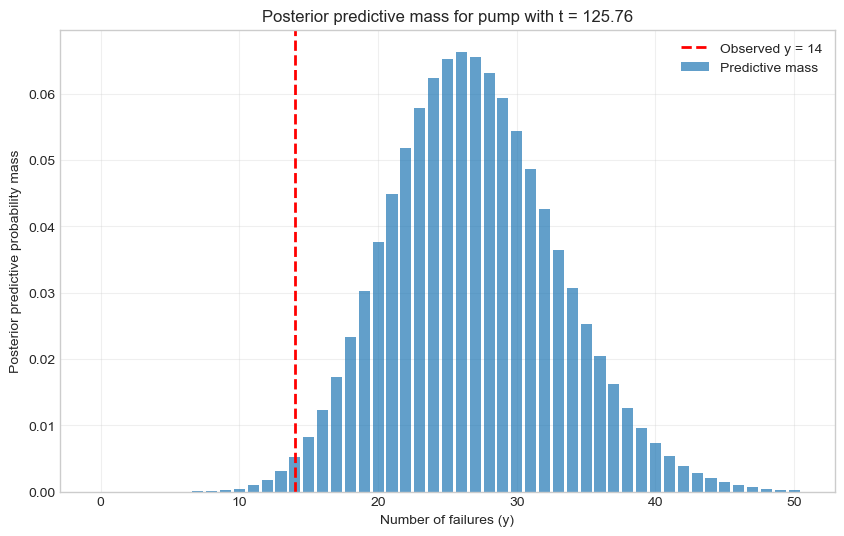

method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False
a_combined = 89.0
b_combined = 475.79200000000003
self.method = symbolic
Predictive mass at y=14: 5.246825e-03


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Parameters for pump 4 ----
t_new = 125.76
y_obs = 14

# ---- Compute predictive mass for y = 0..50 ----
y_vals = np.arange(0, 51)
pred_masses = []

for y in y_vals:
    log_pred = deriv.post_predictive(
        pd.DataFrame({'y': [y]}),
        scale=t_new,
        log=True
    )
    pred_masses.append(np.exp(log_pred))

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.bar(y_vals, pred_masses, width=0.8, alpha=0.7, label='Predictive mass')
plt.axvline(x=y_obs, color='r', linestyle='--', linewidth=2, label=f'Observed y = {y_obs}')
plt.xlabel('Number of failures (y)')
plt.ylabel('Posterior predictive probability mass')
plt.title(f'Posterior predictive mass for pump with t = {t_new}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Also print the predictive mass at the observed value ----
log_pred_obs = deriv.post_predictive(
    pd.DataFrame({'y': [y_obs]}),
    scale=t_new,
    log=True
)
print(f"Predictive mass at y={y_obs}: {np.exp(log_pred_obs):.6e}")

In [8]:
import pandas as pd
import sympy as sp
from jumufraktiv.symbols import t, theta, param
from jumufraktiv.MGFDerivative_class import MGFDerivative

# ---- Assume deriv_sym is a symbolic MGFDerivative object (from previous step) ----
# It should have is_symbolic = True and contain symbolic hyperparameters.

# ---- New observation ----
y_new = 14
t_new = 125.76

# ---- Compute symbolic predictive mass ----
pred_mass_expr = deriv_sym.post_predictive(
    pd.DataFrame({'y': [y_new]}),
    scale=t_new,
    log=False          # return ordinary density (not log)
)

print("Symbolic posterior predictive mass expression:")
sp.pprint(pred_mass_expr, use_unicode=False)

# ---- Optional: simplify ----
pred_mass_expr_simple = sp.simplify(pred_mass_expr)
print("\nSimplified:")
sp.pprint(pred_mass_expr_simple, use_unicode=False)

# ---- Optional: evaluate numerically by substituting hyperparameters ----
# For example, with alpha=2, beta=3 (Gamma prior)
alpha_val = 2.0
beta_val = 3.0
num_val = pred_mass_expr_simple.subs({alpha_sym: alpha_val, beta_sym: beta_val}).evalf()
print(f"\nNumerical predictive mass at y_new={y_new}, t_new={t_new}: {num_val:.6e}")

method = symbolic
t = None
log = False
Reached symbolic branch
t is None? True
⚠️ Symbolic predictive computation failed: Cannot convert expression to float. Falling back to numeric.
method = symbolic
t = np.float64(-475.79200000000003)
log = True
Reached symbolic branch
t is None? False


TypeError: cannot unpack non-iterable Mul object

## 4. Posterior MGF

The posterior MGF as a function of `r` (for `r < 0`):

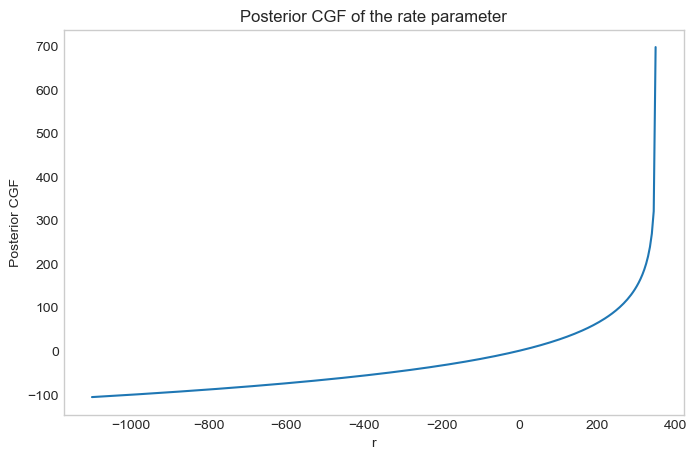

In [7]:
r_vals = np.linspace(-1e3-100, 350, 300)
cgf_vals = [deriv.post_mgf(r, log=True) for r in r_vals]

plt.figure(figsize=(8,5))
plt.plot(r_vals, cgf_vals)
plt.xlabel('r')
plt.ylabel('Posterior CGF')
plt.title('Posterior CGF of the rate parameter')
plt.grid()
plt.show()

## 5. Posterior moments

We compute the first few moments (mean, variance, etc.) using the `post_moment` method.


Number of selected orders: 10
Selected orders (q): [ -75   56  186  317  447  578  708  839  969 1100]
Computing moment for q=-75...
Computed log|E[Θ^-75]| = 193.404546
Computing moment for q=56...
Computed log|E[Θ^56]| = -69.489471
Computing moment for q=186...
Computed log|E[Θ^186]| = -147.688674
Computing moment for q=317...
Computed log|E[Θ^317]| = -157.898561
Computing moment for q=447...
Computed log|E[Θ^447]| = -123.817175
Computing moment for q=578...
Computed log|E[Θ^578]| = -56.362999
Computing moment for q=708...
Computed log|E[Θ^708]| = 36.766040
Computing moment for q=839...
Computed log|E[Θ^839]| = 152.551696
Computing moment for q=969...
Computed log|E[Θ^969]| = 286.095472
Computing moment for q=1100...
Computed log|E[Θ^1100]| = 437.087046
Computed log|E[Θ^q]| values: [193.40454600023287, -69.48947077687356, -147.68867435959586, -157.89856079536966, -123.81717505620409, -56.362999384104995, 36.76604011731885, 152.55169589335003, 286.09547180235177, 437.0870455341491]
sta

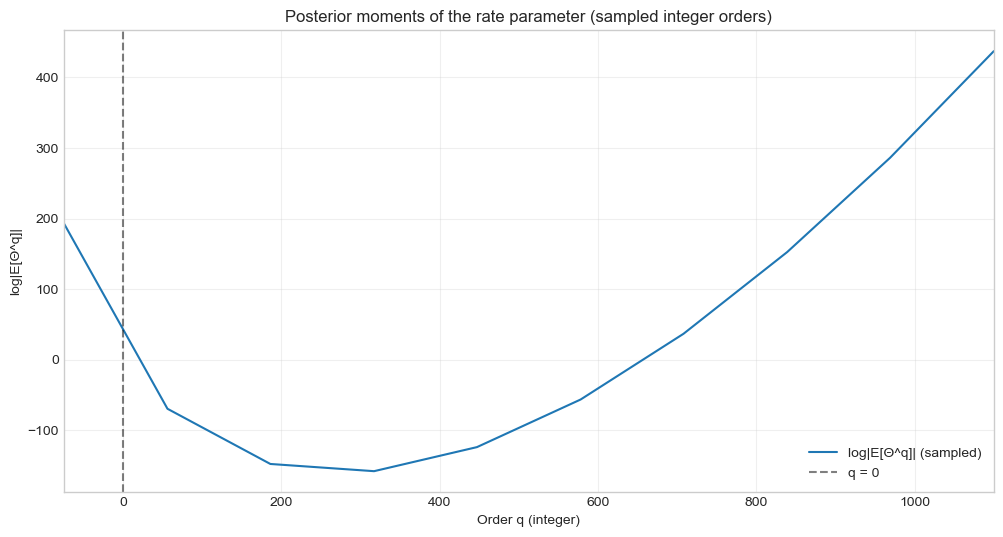

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Compute sufficient statistics ----
a = sum(data['y'])        # Σ y_i (e.g., 75)

# ---- Define order range ----
q_min = -int(a)           # e.g., -75
q_max = 1100

# ---- Select 100 evenly spaced integers between q_min and q_max ----
q_vals = np.unique(np.round(np.linspace(q_min, q_max, 10)).astype(int))
# Ensure q_min and q_max are included (just in case)
if q_min not in q_vals:
    q_vals = np.append(q_min, q_vals)
if q_max not in q_vals:
    q_vals = np.append(q_vals, q_max)
q_vals = np.sort(q_vals)

print(f"Number of selected orders: {len(q_vals)}")
print(f"Selected orders (q): {q_vals}")

# ---- Compute log|E[Θ^q]| for each selected order ----
log_abs_moments = []

for q in q_vals:
    try:
        print(f"Computing moment for q={q}...")
        log_abs = deriv.post_moment(int(q), log=True, numerator_method='symbolic')
        log_abs_moments.append(log_abs)
        print(f"Computed log|E[Θ^{q}]| = {log_abs:.6f}")
    except Exception:
        log_abs_moments.append(np.nan)
        print(f"Warning: Could not compute moment for q={q}. Appending NaN.")

# ---- Plot ----
print(f"Computed log|E[Θ^q]| values: {log_abs_moments}")
log_abs_moments = np.array(log_abs_moments)
print(f"start printing log_abs_moments: {log_abs_moments}")
plt.figure(figsize=(12, 6))
plt.plot(q_vals, log_abs_moments, linestyle='-', linewidth=1.5, label='log|E[Θ^q]| (sampled)')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='q = 0')
plt.xlabel('Order q (integer)')
plt.ylabel('log|E[Θ^q]|')
plt.title('Posterior moments of the rate parameter (sampled integer orders)')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(q_min, q_max)
plt.show()

## 6. Sequential updating

We split the data into two chunks: first 5 pumps, then the remaining 5. We update sequentially and compare the final evidence with the full-dataset evidence.

### JAX-JAX

In [ ]:
import time
from jumufraktiv.mitMGFprior_class import mitMGFprior
import jumufraktiv.MGFdictionary  # registers priors
from jumufraktiv.symbols import t

# ---- Create non‑informative Gamma prior ----
alpha_prior = 1e-5
beta_prior = 1e-5
gamma_prior = mitMGFprior.from_registry(
    "gamma",
    params={"alpha": alpha_prior, "beta": beta_prior}
)

# ---- Split data ----
data1 = data.iloc[:5]
data2 = data.iloc[5:]

# ---- First chunk (sequential) ----
start_seq = time.time()
deriv1 = MGFDerivative(
    prior=gamma_prior,
    data=data1['y'],
    likelihood='poisson',
    method='auto',
    scale=data1['t']
)
print("first set", deriv1)
deriv2 = deriv1.update(
    new_data=data2['y'],
    method='auto',
    scale=data2['t']
)
log_ev_seq = deriv1.evidence()[0] + deriv2.evidence()[0]
time_seq = time.time() - start_seq
print(f"Sequential log evidence: {log_ev_seq:.6f}")
print(f"Sequential time: {time_seq:.3f} seconds")

# ---- Full data (batch) ----
start_full = time.time()
deriv_full = MGFDerivative(
    prior=gamma_prior,
    data=data['y'],
    likelihood='poisson',
    method='jax',
    scale=data['t']
)
log_ev_full, sign_full = deriv_full.evidence()
time_full = time.time() - start_full
print(f"Full data log evidence: {log_ev_full:.6f}")
print(f"Full data time: {time_full:.3f} seconds")

# ---- Compare ----
print(f"Difference in log evidence: {log_ev_seq - log_ev_full:.2e}")
print(f"Speedup (sequential / full): {time_full / time_seq:.2f}x")

first set <jumufraktiv.MGFDerivative_class.MGFDerivative object at 0x30718aa80>
self._is_symbolic = False
type(self.is_symbolic) = <class 'bool'>
symbolic: False


ValueError: Prior does not provide a symbolic MGF (mgf_sym).